In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
import plotting_fn as plot_fn
os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ad_pc = sc.read_h5ad("data/clu7/clu7_pc_densityEst.h5ad")
ad_dm = sc.read_h5ad("data/clu7/clu7_DM_densityEst.h5ad")

In [49]:
sc.settings.set_figure_params(dpi=60, frameon=False, figsize=(4,3))

In [2]:
ad_pc

AnnData object with n_obs × n_vars = 8704 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'u_TIGON_longt', 'u_TIGON_shortt', 'TIGON_v', 'TIGON_g', 'dpt_pseudotime_scaled', 'gaussian_kd

# run mellon (skipped)

In [9]:
import mellon

In [305]:
PC = ad_pc.obsm["X_pca_harmony"][:,:30]
X = ad_dm.obsm["X_diffmap"][:,:10]
X_times = np.log(ad_dm.obs["timepoint_tx_days"].values)

# this code is here to prevent accidental usage of default values on new data
ls_time_estimate = 1.5 * np.mean(np.diff(np.sort(np.unique(X_times))))
print(ls_time_estimate)

0.8430185795500742


In [383]:
# Initialize the time-sensitive density estimator with an intrinsic dimensionality of 2
os.environ['JAX_PLATFORMS'] = "cpu"
t_est = mellon.TimeSensitiveDensityEstimator(d=3, ls_time=ls_time_estimate)

# Fit the estimator to the data
t_est.fit(X, X_times)
density_predictor = t_est.predict

[2025-11-20 08:44:40,876] [INFO    ] Using sparse Gaussian Process since n_landmarks (5,000) < n_samples (8,704) and rank = 1.0.
[2025-11-20 08:44:40,877] [INFO    ] Computing nearest neighbor distances within time points.
[2025-11-20 08:44:41,460] [INFO    ] Using covariance function (Matern52(active_dims=slice(None, -1, None), ls=0.0018866977255834788) * Matern52(active_dims=-1, ls=0.8430185795500742)).
[2025-11-20 08:44:41,464] [INFO    ] Computing 5,000 landmarks with k-means clustering (random_state=42).
[2025-11-20 08:44:52,120] [INFO    ] Using rank 5,000 covariance representation.
[2025-11-20 08:44:56,353] [INFO    ] Running inference using L-BFGS-B.
[2025-11-20 08:45:04,353] [INFO    ] Computing predictive function.


In [307]:
mellon_ub = []

print("DM dimension",X.shape)
for time in sorted(ad_dm.obs["timepoint_tx_days"].unique()):
    print(time)
    log_density = density_predictor(X, np.log(time))
    mellon_ub.append(log_density)
    
    ad_dm.obs[f"log_mellon_DM10_E{time}"] = log_density
    ad_dm.obs[f"log_mellon_DM10_E{time}_clip"] = np.clip(
        log_density, *np.quantile(log_density, [0.05, 1])
    )

mellon_ub = np.stack(mellon_ub)
print(mellon_ub.shape)

DM dimension (8704, 10)
3
7
12
27
49
76
112
161
269
(9, 8704)


In [384]:
ad_dm.obs[f"log_mellon_DM10"] = density_predictor(X, X_times)

In [50]:
# Initialize the time-sensitive density estimator with an intrinsic dimensionality of 2
t_est_pc = mellon.TimeSensitiveDensityEstimator(d=2, ls_time=ls_time_estimate)

# Fit the estimator to the data
t_est_pc.fit(PC, X_times)
density_predictor_pc = t_est_pc.predict

ad_pc.obs["timepoint_tx_days"].unique()

mellon_ub_pc = []

for time in sorted(ad_pc.obs["timepoint_tx_days"].unique()):
    print(time)
    log_density = density_predictor_pc(PC, np.log(time))
    mellon_ub_pc.append(log_density)
    
    ad_pc.obs[f"log_mellon_PC30_E{time}"] = log_density
    ad_pc.obs[f"log_mellon_PC30_E{time}_clip"] = np.clip(
        log_density, *np.quantile(log_density, [0.05, 1])
    )

mellon_ub_pc = np.stack(mellon_ub_pc)
print(mellon_ub_pc.shape)

3
7
12
27
49
76
112
161
269
(9, 8704)


In [200]:
ad_pc.obs[f"log_mellon_PC30"] = density_predictor_pc(PC, X_times)

In [34]:
tompos = sc.read_h5ad("data/tom_pos.h5ad")
ad_dm.uns['pop'] = tompos.uns['pop'].copy()
ad_pc.uns['pop'] = tompos.uns['pop'].copy()

old_umap = ad_dm.obsm['X_umap'].copy()

old_umap[:,0] = -1* old_umap[:,0]

ad_dm.obsm['X_umap'] = old_umap
ad_pc.obsm['X_umap'] = old_umap

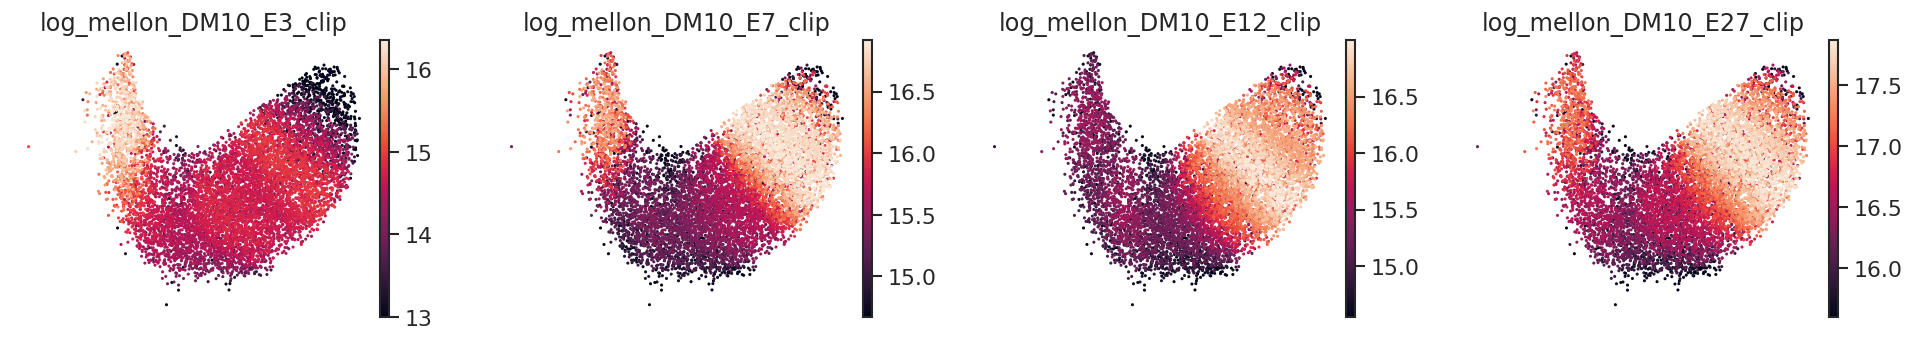

In [311]:
mellon_obs= [
            'log_mellon_DM10_E3_clip',
            'log_mellon_DM10_E7_clip',
            'log_mellon_DM10_E12_clip',
            'log_mellon_DM10_E27_clip',
            'log_mellon_DM10_E49_clip',
            'log_mellon_DM10_E76_clip',
            'log_mellon_DM10_E112_clip',
            'log_mellon_DM10_E161_clip',
            'log_mellon_DM10_E269_clip',
            ]

sc.pl.umap(ad_dm, color=mellon_obs[:4])

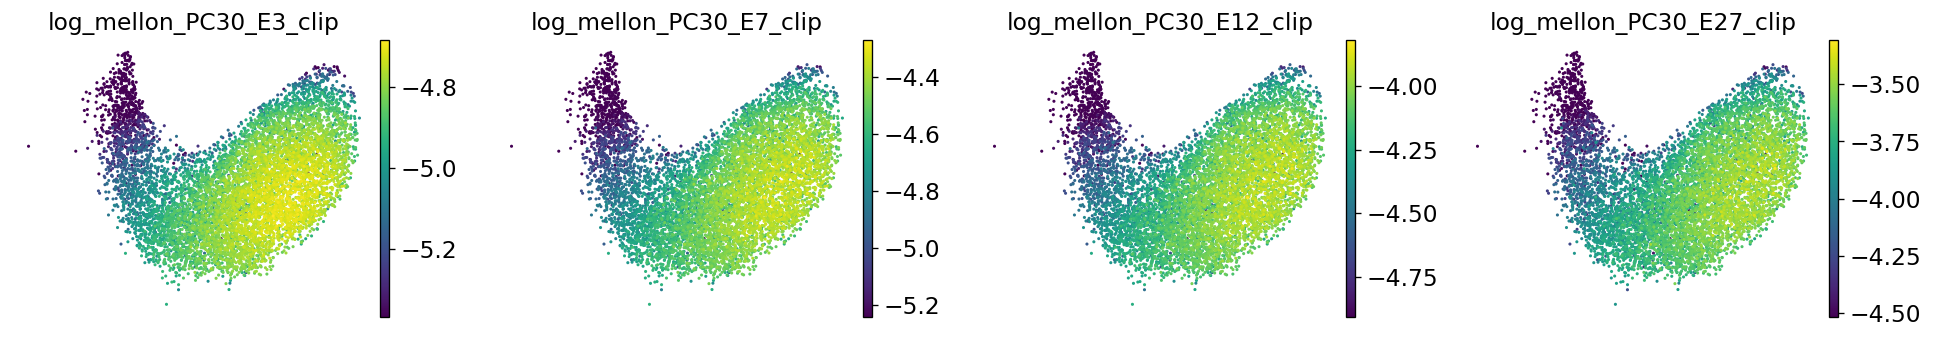

In [84]:
sc.pl.umap(ad_pc, color=[col.replace('DM10','PC30') for col in mellon_obs[:4]])

In [114]:
ad_pc.obs['log_denmarf_PC30'] = np.log(ad_pc.obs['u_TIGON_longt'])

ad_dm.obs['log_denmarf_DM10'] = np.log(ad_dm.obs['denmarf_u_DM10'])
ad_dm.obs['log_denmarf_DM30'] = np.log(ad_dm.obs['denmarf_u_DM30'])

In [201]:
ad_pc.write_h5ad("data/clu7/clu7_pc_densityEst.h5ad")
ad_dm.write_h5ad("data/clu7/clu7_DM_densityEst.h5ad")

## rerun gaussian kde

In [356]:
gussian_kde_u = []

for t in np.unique(ad_dm.obs['timepoint_tx_days']):

    ad_t = ad_dm[ad_dm.obs['timepoint_tx_days'] == t].copy()
    dm = ad_t.obsm["X_diffmap"][:,:10]
    
    kde_fn = gaussian_kde(dm.T,  bw_method=1.5)       # take in [n_dim, n_sample]
    gussian_kde_u.append(kde_fn(dm.T))

gussian_kde_u = np.concatenate(gussian_kde_u, axis=0)
ad_dm.obs[f"kde_dm10"] = gussian_kde_u

# projecting and smoothing functions

In [6]:
import PINN
import torch

from importlib import reload

In [167]:
def project_fn(obs_key, nbins=50, timepoints=None, pseudotime_key='dpt_pseudotime_scaled', timepoint_key='timepoint_tx_days', adata=ad_pc):
    """
    project a obs label onto pseudotime , and return time-wise function

    
    """
    x_ay = []
    y_ay = []

    if timepoints is None:
        timepoints = sorted(adata.obs[timepoint_key].unique())

    # bining
    pdt_max = adata.obs[pseudotime_key].max()
    pdt_bins = np.linspace(0, pdt_max, nbins+1)
    pdt_label = (pdt_bins[1:] + pdt_bins[:-1])/2
    adata.obs['pseudotime_bin'] = pd.cut(adata.obs[pseudotime_key], bins=nbins,
                                                labels = pdt_label)

    for i,t in enumerate(timepoints):



        ad_t = adata[adata.obs[timepoint_key] == t].copy()
        ad_t.obs['pseudotime_bin'] = pd.cut(ad_t.obs[pseudotime_key], bins=nbins,
                                                labels = pdt_label)
        data = ad_t.obs[['pseudotime_bin', obs_key]].copy()

        gdata = data.groupby("pseudotime_bin").agg({obs_key:"mean"}).reset_index()

        gdata[obs_key] = gdata[obs_key].interpolate(method='linear', limit_direction='both')
        gdata[obs_key] = gdata[obs_key].fillna(method='bfill').fillna(method='ffill')

        x_ay.append( np.sort(gdata.pseudotime_bin.unique()) ) 
        y_ay.append( gdata[obs_key].values )

    try:
        x_ay = np.stack(x_ay)
        y_ay = np.stack(y_ay)
    except:
        print("bins not consistent across time")
        pass
    return x_ay, y_ay
    

def smooth_with_ncs(x_ay, y_ay, output_resolution=100):
    """
    smooth the density function with ncs, and output the smoothed density 
    """

    x_ncs = [] 
    u_ncs = []

    for it in range(x_ay.shape[0]):
        nbins = x_ay.shape[1]

        x_knots = torch.from_numpy(x_ay[it])

        y_knots = torch.from_numpy(y_ay[it])

        u_cs = PINN.models.CubicSpline(x=x_knots,
                                        y=y_knots)

        smoothed_x = torch.linspace(0,x_ay.max() , output_resolution+1)
        u_smooth = u_cs(smoothed_x,None).detach().numpy()
        u_smooth = (u_smooth[:-1] + u_smooth[1:])/2 - u_smooth.min()

        norm_u = u_smooth / u_smooth.sum()

        x_ncs.append( (smoothed_x.numpy()[:-1] + smoothed_x.numpy()[1:])/2 )
        u_ncs.append(norm_u)

    return x_ncs, u_ncs


def project_smooth(obs_key, output_resolution=100, **kwargs):
    x, y = project_fn(obs_key, **kwargs)
    x_ncs, u_ncs = smooth_with_ncs(x, y, output_resolution=output_resolution)
    return x_ncs, u_ncs

In [120]:
x, y = project_fn('gaussian_kde_u_dm10', nbins=20)
x_ncs, u_ncs = smooth_with_ncs(x, y)
len(x_ncs), len(u_ncs)

(9, 9)

In [149]:
y.shape

(9, 20)

In [206]:
'log_mellon_PC30' in ad_pc.obs_keys()

True

In [207]:
ad_pc.obs['log_denmarf_PC30'] = np.log(ad_pc.obs['denmarf_u'])

In [209]:
pc30_obs = ['gaussian_kde_u', 'u_TIGON_longt', 'denmarf_u', "log_mellon_PC30"]

pc_den_lookup = {denfn:project_smooth(denfn, adata=ad_pc, nbins=15) for denfn in pc30_obs}

/rds/user/wz369/hpc-work/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))
/rds/user/wz369/hpc-work/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))
/rds/user/wz369/hpc-work/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer

In [ ]:

pc30_obs = [
    'gaussian_kde_u_dm10',
    'TIGON_u_DM10',
    'log_denmarf_DM10',
    'hbe_u_dm10',
    "log_mellon_DM10"
]

# dm10_den_lookup['mellon_DM10'] = mellon_x_ncs, mellon_u_ncs

dm30_den_lookup = {denfn:project_smooth(denfn, adata=ad_dm, nbins=15) for denfn in dm30_obs}

# get ground truth from pseudotime density

In [136]:
from scipy.stats import gaussian_kde, pearsonr, spearmanr 

In [123]:
x_base = dm30_den_lookup['gaussian_kde_u'][0][0]

In [342]:
sc.tl.dpt(ad_dm)

In [345]:
dpt = ad_dm.obs['dpt_pseudotime'].values
dpt_range = dpt.max() - dpt.min()
ad_dm.obs['dpt_pseudotime_scaled'] = (dpt-dpt.min()) / dpt_range

In [346]:

def compute_pdt_kde_u(resolution=0.2):
    dpt_u = []
    dpt_u_mellon_x = [] # mellon x is slightly different

    for t in np.unique(ad_dm.obs['timepoint_tx_days']):
        ad_t = ad_dm[ad_dm.obs['timepoint_tx_days'] == t].copy()
        kde_fn = gaussian_kde(ad_t.obs['dpt_pseudotime_scaled'], bw_method=resolution)

        # dpt u norm
        dpt_u_raw = kde_fn(x_base)
        dpt_u_norm = dpt_u_raw / dpt_u_raw.sum()
        dpt_u.append( dpt_u_norm )

        # dpt u mellon
        dpt_u_m = kde_fn(mellon_x_ncs[0]) # evaluate at mellon x
        dpt_u_mellon_x.append( dpt_u_m / dpt_u_m.sum() )

    dpt_u = np.stack(dpt_u)
    dpt_u_mellon_x = np.stack(dpt_u_mellon_x)

    return dpt_u, dpt_u_mellon_x

dpt_u, dpt_u_mellon_x = compute_pdt_kde_u()
dpt_u_p15, dpt_u_mellon_x = compute_pdt_kde_u(0.15)
dpt_u_p1, dpt_u_mellon_x = compute_pdt_kde_u(0.1)
dpt_u_p05, dpt_u_mellon_x = compute_pdt_kde_u(0.05)
print(dpt_u.shape)


(9, 100)


In [213]:
pc_den_lookup['dpt u'] = [x_base]*9, dpt_u

# projecting diffusion map density

In [385]:
dm30_obs = [
    'gaussian_kde_u',
    'TIGON_u_DM30',
    'log_denmarf_DM30',
    'hbe_u_dm30',
]

dm10_obs = [
    'kde_dm10',
    # 'gaussian_kde_u_dm10',
    'TIGON_u_DM10',
    'log_denmarf_DM10',
    'hbe_u_dm10',
    "log_mellon_DM10"
]

# dm10_den_lookup['mellon_DM10'] = mellon_x_ncs, mellon_u_ncs

dm30_den_lookup = {denfn:project_smooth(denfn, adata=ad_dm, nbins=15) for denfn in dm30_obs}
dm10_den_lookup = {denfn:project_smooth(denfn, adata=ad_dm, nbins=15) for denfn in dm10_obs}

/rds/user/wz369/hpc-work/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))
/rds/user/wz369/hpc-work/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))
/rds/user/wz369/hpc-work/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer

In [ ]:

sns.set_theme(font_scale=0.8)

for obs in dm10_obs:
    fig, axs = plot_fn.umap_by_time(obs,ad_dm, timepoints=[3,7,12,27])
    
    fig.savefig(f'results/density_eval/{obs}_umap.png', dpi=600, transparent=True)

In [ ]:

sns.set_theme(font_scale=0.8)

for obs in pc_den_lookup:
    fig, axs = plot_fn.umap_by_time(obs,ad_pc, timepoints=[3,7,12,27])
    
    fig.savefig(f'results/density_eval/{obs}_PC_umap.png', dpi=600, transparent=True)

In [185]:
np.stack(mellon_u_ncs).sum()

1.0726586492379393

## save as pickle

In [216]:
import pickle as pkl

In [217]:
with open('results/density_eval/PC_density_projection.pkl', 'wb') as handel:
    pkl.dump(pc_den_lookup , handel)
    
with open('results/density_eval/DM10_density_projection.pkl', 'wb') as handel:
    pkl.dump(dm10_den_lookup , handel)
    
with open('results/density_eval/DM30_density_projection.pkl', 'wb') as handel:
    pkl.dump(dm30_den_lookup , handel)

# visaulize projection

## resume projection

In [ ]:
with open('results/density_eval/PC_density_projection.pkl', 'rb') as handel:
    pc_den_lookup = pkl.load( handel)
    
with open('results/density_eval/DM10_density_projection.pkl', 'rb') as handel:
    dm10_den_lookup = pkl.load(handel)
    
with open('results/density_eval/DM30_density_projection.pkl', 'rb') as handel:
    dm30_den_lookup = pkl.load(handel)

## define ploting fun

In [225]:
import seaborn as sns


In [235]:
sns.set_theme(style='ticks', font_scale=1.2)
def plot_over_pdt(smooth_xy_dict, n_timepoints=None, axs=None):

    test_x, test_y = list(smooth_xy_dict.values())[0]
    
    if n_timepoints is None:
        ncol = len(test_y) 
        
    else:
        ncol = n_timepoints
    
    
    if axs is None:
        fig, axs = plt.subplots(1, ncol, figsize=(ncol*5.5, 4), gridspec_kw={'wspace':0.4})

    for obs_key, (x, y) in smooth_xy_dict.items():

        # obs_key : density fun
        # 
        for i, ax in enumerate(axs):
            
            ax.plot(x[i], y[i], label=obs_key)      
            sns.despine(ax=ax)

    return fig, axs

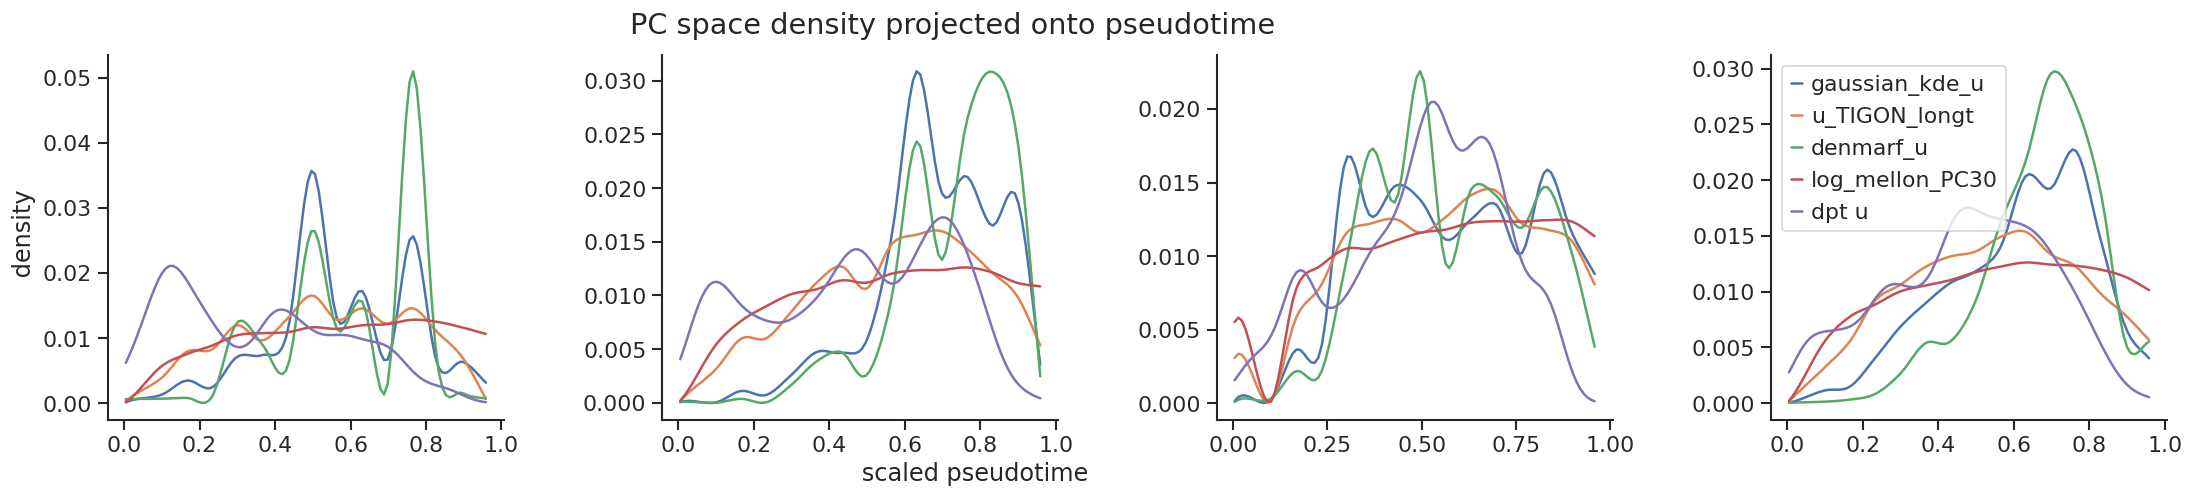

In [236]:
fig, axs = plot_over_pdt(pc_den_lookup, n_timepoints=4)
axs[-1].legend()

axs[0].set_ylabel(" density")
axs[1].set_xlabel("   "*10+"scaled pseudotime")

fig.suptitle("PC space density projected onto pseudotime", y = 1)
fig.savefig("results/density_eval/PC_space_projection_plot.pdf", dpi=600, transparent=True)

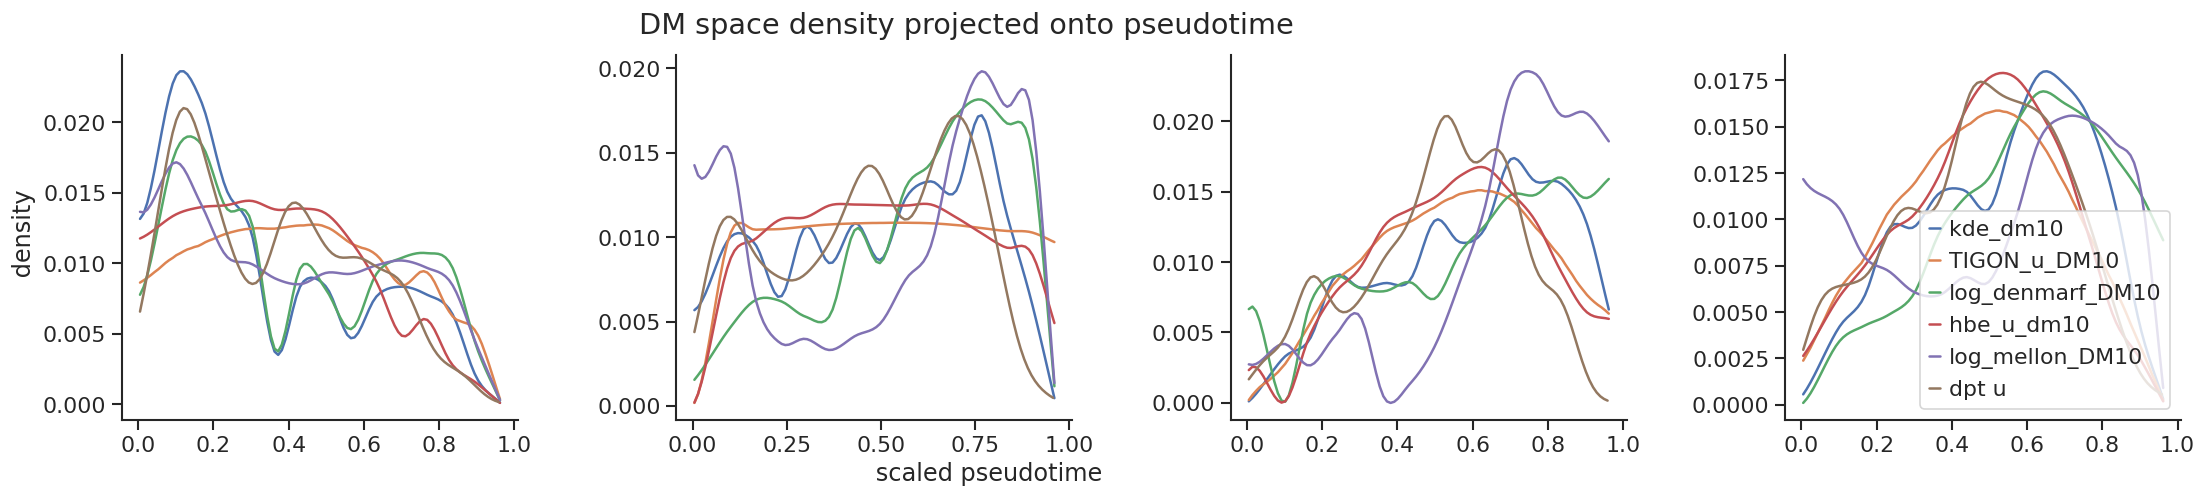

In [407]:
dm10_den_lookup['dpt u'] = [x_base]*9, dpt_u
fig,axs = plot_over_pdt(dm10_den_lookup, n_timepoints=4)
axs[-1].legend()

axs[0].set_ylabel(" density")
axs[1].set_xlabel("   "*10+"scaled pseudotime")

fig.suptitle("DM space density projected onto pseudotime", y = 1)
fig.savefig("results/density_eval/DM10_space_projection_plot.pdf", dpi=600, transparent=True)

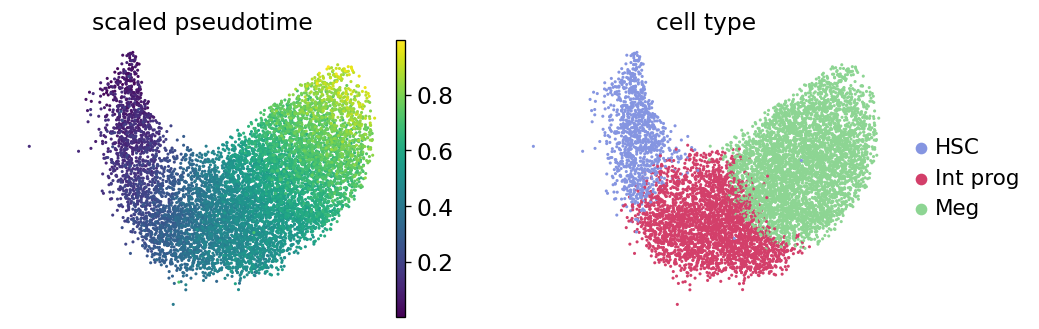

In [ ]:
fig

In [ ]:
fig = sc.pl.umap(ad_dm, color=['dpt_pseudotime_scaled', 'anno_man'], return_fig=True)
fig.axes[0].set_title('scaled pseudotime')
fig.axes[2].set_title('cell type')

fig.savefig('results/density_eval/clu7_umap.png', dpi=600, transparent=True)

# evaluate

In [349]:
dpi = 600
fig, axs = plt.subplots(1,4,figsize=(16,3), gridspec_kw={'wspace':0.5}, dpi=dpi)


timepoints = [3,7,12,27]
        
for i in range(4):
    axs[i].plot(x_base, dpt_u[i])
    axs[i].set_title(f'd{timepoints[i]}')

axs[0].set_ylabel(" density")

axs[1].set_xlabel("   "*10+"scaled pseudotime")

fig.suptitle("Guassian kernel density along pseudotime", y = 1.3)

fig.savefig('results/density_eval/ground_truth_projection.pdf', dpi=dpi)

## compute r and kld

In [241]:
from scipy.special import kl_div
from scipy.stats import gaussian_kde, pearsonr, spearmanr 

In [378]:
def compute_across_method(lookup=dm10_den_lookup, ground_truth=dpt_u):

    r_dict = []
    spr_dict = []
    kld_dict = []
    timepoints = 4


    for method, (x, u_test) in lookup.items():

        r = []
        kld = []
        spr = []
        for i in range(timepoints):

            if method =='dpt u':
                continue

            r.append(pearsonr(u_test[i], ground_truth[i])[0]) 
            spr.append(spearmanr(u_test[i], ground_truth[i])[0]) 
            kld.append(kl_div(u_test[i], ground_truth[i])[0]) 

        r_dict.append( np.array(r) )
        kld_dict.append(  np.array(kld) )
        spr_dict.append( np.array(spr) )

    r_df = pd.DataFrame(r_dict, index=lookup.keys()).T
    r_df['timeoints'] = [3,7,12,27]
    r_df['metric'] = 'pearson r'

    spr_df = pd.DataFrame(spr_dict, index=lookup.keys()).T
    spr_df['timeoints'] = [3,7,12,27]
    spr_df['metric'] = 'spearman r'

    kld_df = pd.DataFrame(kld_dict, index=lookup.keys()).T
    kld_df['timeoints'] = [3,7,12,27]
    kld_df['metric'] = 'kl div'

    perform_df = pd.concat([r_df, spr_df, kld_df], axis=0)


    return perform_df

In [387]:
resolution = [0.2,0.15,0.1]

dm_perform_ls = []


for i, true_u in enumerate([dpt_u, dpt_u_p15, dpt_u_p1]):

    dm_perform = compute_across_method(lookup=dm10_den_lookup, ground_truth=true_u)
    dm_perform['resolution'] = resolution[i]
    dm_perform['space'] = '10DM'
    
    dm_perform_ls.append(dm_perform)
    
dm_perform = pd.concat(dm_perform_ls, axis=0)
dm_perform.to_csv('results/density_eval/DM10_eval_df.csv')

In [388]:
dm_flat = dm_perform.melt(id_vars=['timeoints','metric','resolution','space'], var_name='method')

In [389]:
dm_flat.head()

,timeoints,metric,resolution,space,method,value
0,3,pearson r,0.2,10DM,kde_dm10,0.747168
1,7,pearson r,0.2,10DM,kde_dm10,0.680965
2,12,pearson r,0.2,10DM,kde_dm10,0.520913
3,27,pearson r,0.2,10DM,kde_dm10,0.733508
4,3,spearman r,0.2,10DM,kde_dm10,0.573880


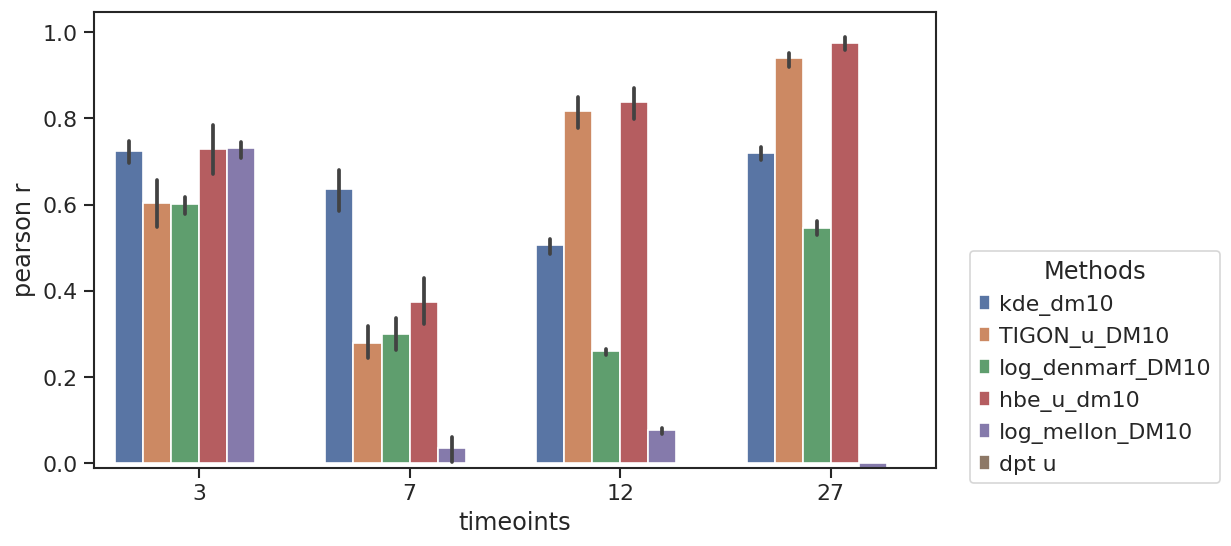

In [408]:
fig = plt.figure(figsize=(9,5))
ax=fig.gca()
sns.barplot(data=dm_flat.query('metric == "pearson r"'), 
            hue = 'method',  
            y = "value", 
            x='timeoints',
            ax=ax
           )

ax.legend(bbox_to_anchor=[1.35,0.5], title='Methods')
ax.set_ylim(-0.01,None)
ax.set_ylabel('pearson r')

fig.savefig('results/density_eval/DM_pearon_r.pdf', dpi=600, transparent=True)

In [402]:
resolution = [0.2,0.15,0.1,0.05]

pc_perform_ls = []


for i, true_u in enumerate([dpt_u, dpt_u_p15, dpt_u_p1, dpt_u_p05]):

    pc_perform = compute_across_method(lookup=pc_den_lookup, ground_truth=true_u)
    pc_perform['resolution'] = resolution[i]
    pc_perform['space'] = '30PC'
    
    pc_perform_ls.append(pc_perform)
    
pc_perform = pd.concat(pc_perform_ls, axis=0)

In [403]:
pc_perform.to_csv('results/density_eval/PC30_eval_df.csv')

In [404]:
pc_flat = pc_perform.melt(id_vars=['timeoints','metric','resolution','space'], var_name='method')

In [405]:
pc_flat.head()

,timeoints,metric,resolution,space,method,value
0,3,pearson r,0.2,30PC,gaussian_kde_u,-0.238514
1,7,pearson r,0.2,30PC,gaussian_kde_u,0.337959
2,12,pearson r,0.2,30PC,gaussian_kde_u,0.510993
3,27,pearson r,0.2,30PC,gaussian_kde_u,0.535494
4,3,spearman r,0.2,30PC,gaussian_kde_u,-0.278219


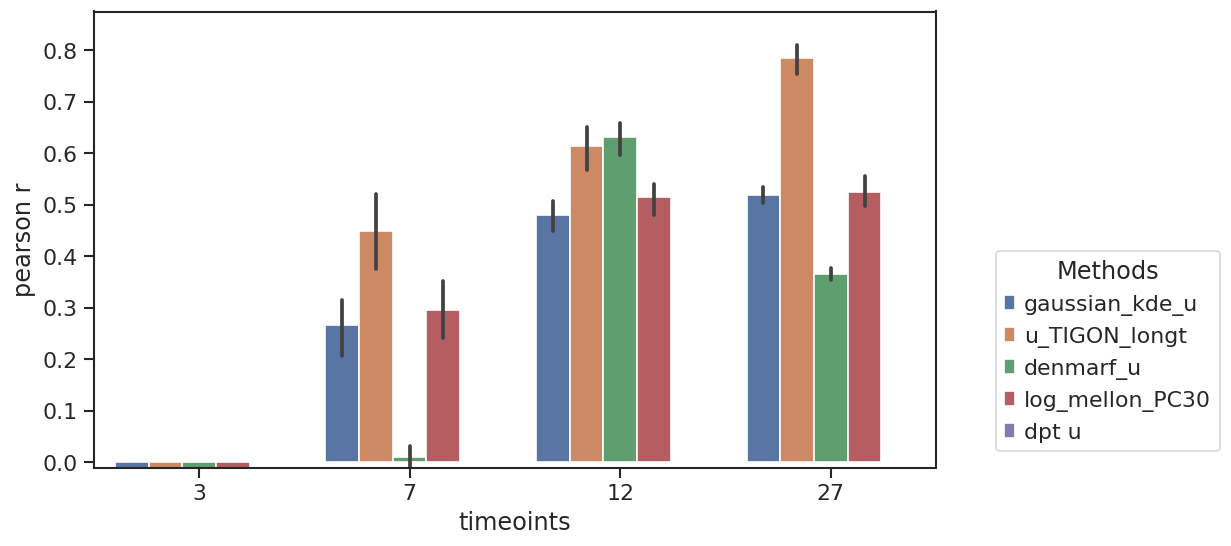

In [409]:
fig = plt.figure(figsize=(9,5))
ax=fig.gca()
sns.barplot(data=pc_flat.query('metric == "pearson r"'), 
            hue = 'method',  
            y = "value", 
            x='timeoints',
            ax=ax
           )

ax.legend(bbox_to_anchor=[1.35,0.5], title='Methods')
ax.set_ylim(-0.01,None)
ax.set_ylabel('pearson r')

fig.savefig('results/density_eval/PC_pearon_r.pdf', dpi=600, transparent=True)